<a href="https://colab.research.google.com/github/robertzengcn/cnn_cifar10/blob/master/Animal_face_classify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: jianzezeng
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:07<00:00, 102MB/s]


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset,DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"
print("Device available is",device)

Device available is cuda


In [ ]:
image_path=[]
labels=[]
for i in os.listdir(f"/content/animal-faces/afhq"):
  # print(i)
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    # print(label)
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)
      # print(image)
  #     break
  #   break
  # break
      # image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      # labels.append(label)
data_df=pd.DataFrame(zip(image_path,labels),columns=["image_path","labels"])
data_df.head()

,image_path,labels
0,/content/animal-faces/afhq/train/wild/flickr_w...,wild
1,/content/animal-faces/afhq/train/wild/pixabay_...,wild
2,/content/animal-faces/afhq/train/wild/flickr_w...,wild
3,/content/animal-faces/afhq/train/wild/flickr_w...,wild
4,/content/animal-faces/afhq/train/wild/flickr_w...,wild


In [ ]:
train=data_df.sample(frac=0.7,random_state=7)
test=data_df.drop(train.index)

val=test.sample(frac=0.5,random_state=7)
test=test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

(11291, 2)
(2420, 2)
(2419, 2)


In [ ]:
label_encoder=LabelEncoder()
label_encoder.fit(data_df["labels"])

transform=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [ ]:
class CustomImageDataset(Dataset):
  def __init__(self,dataframe,transform=None):
    self.dataframe=dataframe
    self.transform=transform
    self.labels=torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]
  def __getitem__(self,idx):
    img_path=self.dataframe.iloc[idx,0]
    label=self.labels[idx]
    image=Image.open(img_path).convert('RGB')
    if self.transform:
      image=self.transform(image).to(device)
    return image,label

In [ ]:
train_dataset=CustomImageDataset(dataframe=train,transform=transform)
val_dataset=CustomImageDataset(dataframe=val,transform=transform)
test_dataset=CustomImageDataset(dataframe=test,transform=transform)

In [ ]:
train_dataset.__len__()

11291

In [ ]:
train_dataset.__getitem__(2)

(tensor([[[0.8078, 0.8157, 0.8157,  ..., 0.8157, 0.8392, 0.8510],
          [0.7961, 0.8118, 0.8157,  ..., 0.8078, 0.8392, 0.8510],
          [0.7725, 0.8039, 0.8078,  ..., 0.7922, 0.8353, 0.8510],
          ...,
          [0.8745, 0.8784, 0.8824,  ..., 0.8824, 0.8784, 0.8784],
          [0.8941, 0.8941, 0.8941,  ..., 0.8784, 0.8784, 0.8784],
          [0.9020, 0.9020, 0.8941,  ..., 0.8784, 0.8784, 0.8784]],
 
         [[0.8118, 0.8196, 0.8196,  ..., 0.8157, 0.8392, 0.8510],
          [0.8000, 0.8157, 0.8196,  ..., 0.8078, 0.8392, 0.8510],
          [0.7765, 0.8078, 0.8118,  ..., 0.7922, 0.8353, 0.8510],
          ...,
          [0.8784, 0.8824, 0.8863,  ..., 0.8863, 0.8824, 0.8824],
          [0.8980, 0.8980, 0.8980,  ..., 0.8824, 0.8824, 0.8824],
          [0.9059, 0.9059, 0.8980,  ..., 0.8824, 0.8824, 0.8824]],
 
         [[0.8196, 0.8275, 0.8275,  ..., 0.8235, 0.8471, 0.8588],
          [0.8078, 0.8235, 0.8275,  ..., 0.8157, 0.8471, 0.8588],
          [0.7843, 0.8157, 0.8196,  ...,

In [ ]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

In [ ]:
data_df.sample(n=1)

,image_path,labels
8978,/content/animal-faces/afhq/train/dog/pixabay_d...,dog


In [ ]:
data_df.sample(n=1)["image_path"]

,image_path
9053,/content/animal-faces/afhq/train/dog/pixabay_d...


In [ ]:
data_df.sample(n=1)["image_path"].iloc[0]

'/content/animal-faces/afhq/train/wild/flickr_wild_003744.jpg'

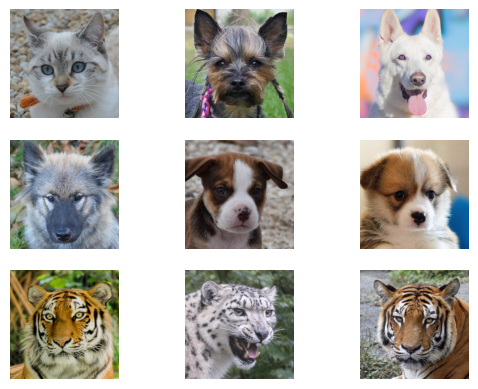

In [ ]:
n_rows=3
n_cols=3
f,axarr=plt.subplots(n_rows,n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image=Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')
plt.show()

In [ ]:
LR=1e-4
BATCH_SIZE=16
EPOCHS=10


In [ ]:
train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=True)

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv2d(3,32,kernel_size=3,padding=1)
    self.conv2=nn.Conv2d(32,64,kernel_size=3,padding=1)
    self.conv3=nn.Conv2d(64,128,kernel_size=3,padding=1)
    self.pooling=nn.MaxPool2d(2,2)
    self.relu=nn.ReLU()
    self.flatten=nn.Flatten()
    self.linear=nn.Linear((128*16*16),128)
    #https://www.bilibili.com/video/BV1J5gpzBEpa/?vd_source=cf6fc916dd58a2dc2b976206d78d5e8e 2:09:55有讲解
    self.output=nn.Linear(128,len(data_df['labels'].unique()))
  def forward(self,x):
    x=self.conv1(x) #=>(32,128,128)
    x=self.pooling(x) #=>(32,64,64)
    x=self.relu(x)

    x=self.conv2(x)  #=>(64,64,64)
    x=self.pooling(x) #=>(64,32,32)
    x=self.relu(x)

    x=self.conv3(x)  #=>(128,32,32)
    x=self.pooling(x) #=>(128,16,16)
    x=self.relu(x)

    x=self.flatten(x)
    x=self.linear(x)
    x=self.output(x)
    return x

In [ ]:
model=Net().to(device)

In [ ]:
from torchsummary import summary
summary(model,input_size=(3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [ ]:
criterion=nn.CrossEntropyLoss()
optimizer=Adam(model.parameters(),lr=LR)

In [ ]:
total_loss_train_plot=[]
total_loss_validation_plot=[]
total_acc_train_plot=[]
total_acc_validation_plot=[]

for epoch in range(EPOCHS):
  total_acc_train=0
  total_loss_train=0
  total_loss_val=0
  total_acc_val=0

  for inputs,labels in train_loader:
    optimizer.zero_grad()
    outputs=model(inputs)
    train_loss=criterion(outputs,labels)
    total_loss_train+=train_loss.item()

    train_loss.backward()
    train_acc=(torch.argmax(outputs,axis=1)==labels).sum().item()
    # print(torch.argmax(outputs,axis=1)==labels)
    # print((torch.argmax(outputs,axis=1)==labels).sum().item())
    total_acc_train+=train_acc
    optimizer.step()
  with torch.no_grad():
    for inputs,val_labels in val_loader:
      outputs=model(inputs)
      val_loss=criterion(outputs,val_labels)
      total_loss_val+=val_loss.item()
      val_acc=(torch.argmax(outputs,axis=1)==val_labels).sum().item()
      total_acc_val+=val_acc
  total_loss_train_plot.append(round(total_loss_train/1000,4))
  total_loss_validation_plot.append(round(total_loss_val/1000,4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100,4))
  total_acc_validation_plot.append(round(total_acc_val/(val_dataset.__len__())*100,4))

  print(f'''Epoch{epoch+1}/{EPOCHS},Train Loss:{round(total_loss_train/100,4)}
     Train Accuracy {round(total_acc_train/train_dataset.__len__(),4)}
     Validation Loss {round(total_loss_train/100,4)}
     Validation Accuracy {round(total_acc_val/val_dataset.__len__()*100,4)}
    ''')
  print("="*25)

Epoch1/10,Train Loss:0.0973
     Train Accuracy 0.996
     Validation Loss 0.0973
     Validation Accuracy 94.3388
    
Epoch2/10,Train Loss:0.1012
     Train Accuracy 0.9955
     Validation Loss 0.1012
     Validation Accuracy 95.8678
    
Epoch3/10,Train Loss:0.0694
     Train Accuracy 0.9973
     Validation Loss 0.0694
     Validation Accuracy 95.2479
    
Epoch4/10,Train Loss:0.085
     Train Accuracy 0.9961
     Validation Loss 0.085
     Validation Accuracy 96.0744
    
Epoch5/10,Train Loss:0.0549
     Train Accuracy 0.9975
     Validation Loss 0.0549
     Validation Accuracy 96.0744
    
Epoch6/10,Train Loss:0.0953
     Train Accuracy 0.9957
     Validation Loss 0.0953
     Validation Accuracy 95.9917
    
Epoch7/10,Train Loss:0.0392
     Train Accuracy 0.9982
     Validation Loss 0.0392
     Validation Accuracy 96.6116
    
Epoch8/10,Train Loss:0.0418
     Train Accuracy 0.9983
     Validation Loss 0.0418
     Validation Accuracy 96.7355
    
Epoch9/10,Train Loss:0.0093
     Tr

In [ ]:
with torch.no_grad():
  total_loss_test=0
  total_acc_test=0
  for inputs, lables in test_loader:
    prediction=model(inputs)
    acc=(torch.argmax(prediction,axis=1)==lables).sum().item()
    total_acc_test+=acc
    test_loss=criterion(prediction,lables)
    total_loss_test+=test_loss.item()
print(f"Accuracy Score is:{round((total_acc_test/test_dataset.__len__())*100,4)} and Loss is {round(total_loss_test/100,400)}")

Accuracy Score is:94.0058 and Loss is 0.41435634559392476


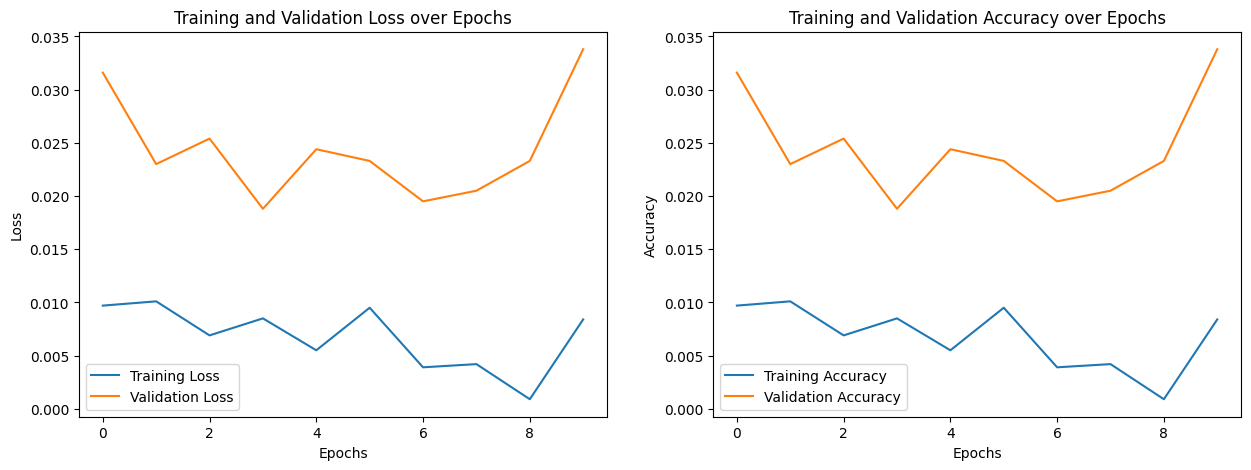

In [ ]:
fig,axs=plt.subplots(nrows=1,ncols=2,figsize=(15,5))
axs[0].plot(total_loss_train_plot,label="Training Loss")
axs[0].plot(total_loss_validation_plot,label="Validation Loss")
axs[0].set_title("Training and Validation Loss over Epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(total_loss_train_plot,label="Training Accuracy")
axs[1].plot(total_loss_validation_plot,label="Validation Accuracy")
axs[1].set_title("Training and Validation Accuracy over Epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].legend()

plt.show()


In [ ]:
def predict_image(img_path):
  image=Image.open(img_path).convert('RGB')
  image=transform(image).to(device)
  output=model(image)
  output=torch.argmax(output,axis=1).item()

  return label_encoder.inverse_transform([output])

In [ ]:
#predict_image(img_path)
